#### Teoría de los Circuitos 2
# Trabajo semanal 8
#### Leandro Robledo

1. Sea la función Inmitancia:
\begin{equation}
 F(s)=\frac{S^4+4S+3}{s(s^2+2)} 
\end{equation}

Se pide hallar la topología circuital y los valores de los componentes

a) Síntesis de $Z(s)$ mediante el método de Foster en su versión serie

b) Síntesis de $Y(s)$ mediante el método de Foster en su versión derivación

c) Síntesis de $Z(s)$ mediante el método de Cauer remoción en infinito 

d) Síntesis de $Z(s)$ mediante el método de Cauer remoción en DC  

e) Simular $Z(s)$ en LTSpice , observando los cambios de fase y la ley de variación ( pendiente ) de la impedancia total de la red. 



a) Primero se procede sacando el valor de continua el cual en parametros Z es representado como un capacitor en serie, luego el valor de K infinito que se obtiene una nonina en serie y por ultimo la expresion restante corresponde a un tanque resonante.

b) De forma similar en parametros Y se saca el K en 0 el cual en estos parametros es una bobina en derivacion, asi como el K infinto corresponde a un capacitor. Por ultimo el tanque resonante compuesto por un LC que en esta ocacion se encuentra en serie. 

![Foster z e Y](Foster_ZY.jpeg)
![modulo de impedancia ](modulo_foster_imp.PNG)



c) Apoyandonos en el metodo grafico y haciendo las remociones parciales con las divisiones se llega al circuito siguiente. 

![Cauer_infinito](Cauer_inf.jpeg)
![modulo de Caueer en infinito ](Cauer_inf.PNG)


d) Similarmente haciendo las remociones parciales con las divisiones ahora invertidas se llega al circuito siguiente. 

![Cauer_DC](Cauer_0.jpeg)
![modulo de Caueer en infinito ](CAuer_cero.PNG)

e)Estos fueron los circuitos obtenidos que se simularon en los graficos anteriores:

![Circuitos obtenidos](circuitos_Z.PNG)

2. Sea la siguiente red , pensandolo como una inmitancia
   
![Circuito lc](Circuito_LC.PNG)


a) Hallar el valor de los componentes sabiendo que satisface la función admitancia propuesta 
\begin{equation}
\frac{s^5 + 18s^3 + 48s}{6s^4+ 42s^2 +48}
\end{equation}


Comienzo utilizando Cauer en infinito donde obtengo los primeros dos parametros los cuales son un capacitor en serie y una bobina en derivacion. 

Posterior a eso como me encuentro con un tanque LC en paralelo utilizo los parametros Z de foster para sacar ambos parametros

Finalmente, se utiliza foster para obtener el valor del ultimo capacitor
![solucion_circuito lc](LC.jpeg)


3. Encuentre el valor de los elementos que integran el siguiente circuito y que satisface la función impedancia propuesta:
   ![Circuito rlc](Circuito_RLC.PNG)
\begin{equation}
\frac{s^2 + 6s + 8s}{s^2+ 6s +5}
\end{equation}

La complicacion de este circuito es que lo primero que se intentaria realizar es extraer la resistencia que aparece, sin embargo, no se la puede analizar por foster ya que al ser un circuito RLC, el asumirlo como un K infinito o un K en DC esta perdiendo informacion ya que estaria removiendo al mismo tiempo el valor de la resistencia de los tanques resonantes. 

Como solucion se extrajo entonces el tanque RC ya que segun los calculos es el que utilizando la sintesis de residuos RC justamente eran daban el K intermedio positivo. Una vez removido este tanque se puede analizar en continua e infinto ya que en este primer caso solo quedaria la R1 que quisimos sacar al inicio ya que la bobina se shortearia, mientras que en el segundo caso queda R1 y R2 por lo que con un sistema de ecuaciones se puede obtener el primer valor.

Finalmente con esta ultima remocion se obtiene un tanque resonante RL, el cual se obtienen sus valores con un simple analisis. 

![solucion_circuito rlc](RLC.jpeg)
![solucion_circuito rlc](RLC_2.jpeg)


### Bonus

💎 Implementar en Python el punto 1 verificando los resultados usando las funciones de pytc2 : 
dibujar_foster_serie ; dibujar_foster_derivacion ; dibujar_cauer_LC; 


In [6]:
import sympy as sp

# Ahora importamos las funciones de PyTC2

from pytc2.sintesis_dipolo import foster
from pytc2.dibujar import dibujar_foster_serie, dibujar_foster_derivacion
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s

# Importante importar símbolos de variables 
from pytc2.general import s

In [8]:
# Sea la siguiente función de excitación
FF = (s**4 + 4*s **2 + 3)/((s)*(s**2+2))

print_latex(a_equal_b_latex_s('F(s)', FF))

<IPython.core.display.Math object>

In [9]:
# Se expande FF a la Foster
k0, koo, ki_wi, _, FF_foster = foster(FF)

print_latex(a_equal_b_latex_s('k_0', k0))

print_latex(a_equal_b_latex_s(r'k_1 = \left[ \frac{1}{ \frac{1}{s. \frac{\omega_i^2}{2.k_i} } + s . \frac{1}{2.k_i} } \right]  = \
                                             \left[ \frac{1}{ \frac{k_0}{s} + s . k_\infty } \right] = \
                                             \left[ k_0, k_\infty \right] = \
                                       \left[ \
                                             \left[ \frac{\omega_1^2}{2k_1}, \frac{1}{2k_1} \right] \
                                       \right]', ki_wi ))

print_latex(a_equal_b_latex_s('k_\infty', koo))


print_latex(a_equal_b_latex_s(a_equal_b_latex_s('F(s)', FF)[1:-1], FF_foster ))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Foster serie

<IPython.core.display.Math object>

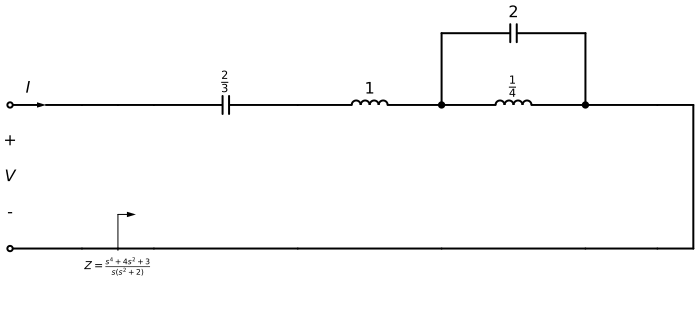

In [10]:
print_subtitle('Foster serie')

print_latex(a_equal_b_latex_s(a_equal_b_latex_s('Z(s)=F(s)', FF)[1:-1], FF_foster ))

# Tratamos a nuestra función imitancia como una Z
dibujar_foster_serie(k0, koo, ki_wi, z_exc = FF)

#### Foster derivacion

#### Foster derivación

<IPython.core.display.Math object>

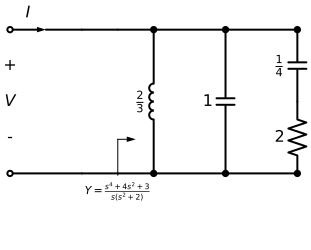

In [11]:
print_subtitle('Foster derivación')

print_latex(a_equal_b_latex_s(a_equal_b_latex_s('Y(s)=F(s)', FF)[1:-1], FF_foster ))

# Tratamos a nuestra función imitancia como una Y
dibujar_foster_derivacion(k0, koo, ki_wi, y_exc = FF)

### Cauer

In [13]:
from pytc2.sintesis_dipolo import cauer_LC
from pytc2.dibujar import dibujar_cauer_LC


# Sea la siguiente función de excitación
FF = (s**4 + 4*s **2 + 3)/((s)*(s**2+2))

print_latex(a_equal_b_latex_s('F(s)', FF))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

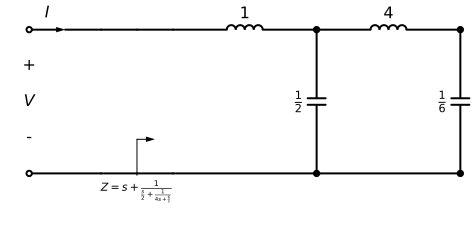

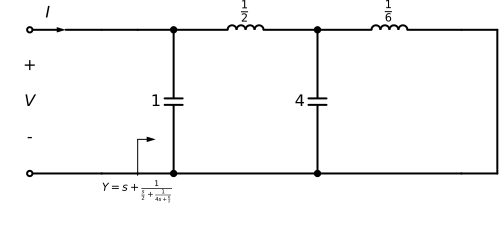

In [14]:
# Implementaremos FF mediante Cauer 1 o remociones continuas en infinito
koo, F_cauer_oo, rem = cauer_LC(FF, remover_en_inf=True)

print_latex(a_equal_b_latex_s(a_equal_b_latex_s('F(s)', FF)[1:-1], F_cauer_oo ))

# Tratamos a nuestra función inmitancia como una Z
dibujar_cauer_LC(koo, z_exc = F_cauer_oo)

# Tratamos a nuestra función inmitancia como una Y
dibujar_cauer_LC(koo, y_exc = F_cauer_oo)

<IPython.core.display.Math object>

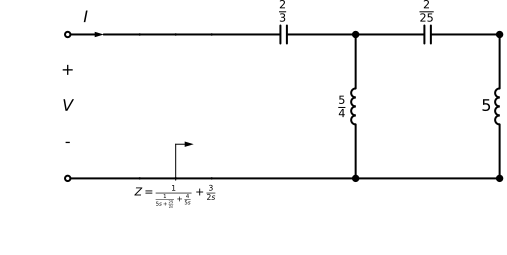

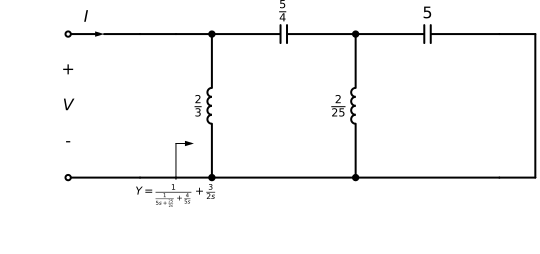

In [15]:
# Implementaremos F mediante Cauer 2 o remociones continuas en cero
k0, F_cauer_0, rem = cauer_LC(FF, remover_en_inf=False)

print_latex(a_equal_b_latex_s(a_equal_b_latex_s('F(s)', FF)[1:-1], F_cauer_0 ))

# Tratamos a nuestra función inmitancia como una Z
dibujar_cauer_LC(k0, z_exc = F_cauer_0)

# Tratamos a nuestra función inmitancia como una Y
dibujar_cauer_LC(k0, y_exc = F_cauer_0)

Simulación circuital del punto 2. Medir la admitancia y explicar comportamiento en DC 

Dado que la Admitancia de entrada tenia la siguiente forma:
\begin{equation}
Y(s)=\frac{s^5 + 18s^3 + 48s}{6s^4+ 42s^2 +48}
\end{equation}

Se observa que haciendo 
\begin{equation}
\lim_{s\to 0} Y(s)=0
\end{equation}
Lo que se puede ver en la simulacion, ya que se aprecia como cuando nos acercamos a 0 la misma tiende a -inf en db.  
![simulacion LC en DC](simu_LC.PNG)

Esto coincide con lo esperado ya que al ser una admitancia que en DC tiende a 0 se espera una impedancia de entrada infinta, justamente lo que nos indica el tener un capacitor en serie a la emtrada del sistema. 